In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('train.csv')
df_full = pd.read_excel('US_dataQ.xlsx')
cols = ['FEDFUNDS', 'DTWEXBGS', 'GDPC1', 'CPIAUCSL', 'RTWEXBGS']

def transform(frame):
    out = frame.assign(Date=pd.to_datetime(frame['Date'])).set_index('Date')[cols].astype(float).sort_index()
    out['FEDFUNDS'] = out['FEDFUNDS'].diff()
    out[cols[1:]] = np.log(out[cols[1:]]).diff()
    return out.dropna()

data, data_full = transform(df), transform(df_full)
train_end = data.index.max()

# Преобразования:

На 1 квартал вперед:

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
\sin\left(
\mathrm{FEDFUNDS}_{t-1}
\left(
1.5105-\mathrm{FEDFUNDS}_{t-3}
\right)
\right)
$$

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
1.4905\,
\sin\left(
\mathrm{FEDFUNDS}_{t-1}
\left(
\mathrm{FEDFUNDS}_{t-3}-1.0672
\right)^2
\right)
$$

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
1.545\,
\sin\left(
\mathrm{FEDFUNDS}_{t-1}
\left(
\mathrm{FEDFUNDS}_{t-3}
+
\mathrm{DTWEXBGS}_{t-2}
-
1.0757
\right)^2
\right)
$$

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
1.6005\,
\sin\left(
\mathrm{FEDFUNDS}_{t-1}
\left(
\mathrm{FEDFUNDS}_{t-3}
-
1.0543
-
3.8208\,
\mathrm{DTWEXBGS}_{t-2}
\mathrm{FEDFUNDS}_{t-2}
\right)^2
\right)
$$

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
\left(
1.0085
+
\frac{\mathrm{CPIAUCSL}_{t-1}}{0.02507}
\right)
\sin\left(
\mathrm{FEDFUNDS}_{t-1}
\left[
1+
\left(
\mathrm{FEDFUNDS}_{t-3}-0.54019
\right)^2
-
\mathrm{FEDFUNDS}_{t-3}
\right]
\right)
$$

$$
\widehat{\mathrm{FEDFUNDS}}_t
=
\left(
0.99788
+
\frac{\mathrm{CPIAUCSL}_{t-3}}{0.025327}
-
\frac{\mathrm{DTWEXBGS}_{t-2}}{0.081413}
\right)
\sin\left(
\mathrm{FEDFUNDS}_{t-1}
\left[
1+
\left(
\mathrm{FEDFUNDS}_{t-3}-0.51752
\right)^2
-
\mathrm{FEDFUNDS}_{t-3}
\right]
\right)
$$

На 2 квартала вперед:

$$
\widehat{\mathrm{DTWEXBGS}}_{t+1}
=
6.0423\,\mathrm{RTWEXBGS}_{t-1}
+
\sin\left(
\sin\left(\mathrm{FEDFUNDS}_{t-1}\right)
\right)
$$

$$
\widehat{\mathrm{DTWEXBGS}}_{t+1}
=
\sin\left(\mathrm{FEDFUNDS}_{t-1}\right)
+
0.4145\,
\sin\left(
12.67\,\mathrm{FEDFUNDS}_{t-1}
\right)
-
\frac{\mathrm{GDPC1}_{t-1}}{0.11288}
$$

$$
\widehat{\mathrm{DTWEXBGS}}_{t+1}
=
0.41701\,
\sin\left(
12.597
\left(
\mathrm{FEDFUNDS}_{t-1}
+
\mathrm{GDPC1}_{t-1}
\right)
\right)
+
\sin\left(\mathrm{FEDFUNDS}_{t-1}\right)
-
\frac{\mathrm{GDPC1}_{t-1}}{0.12789}
$$

$$
\widehat{\mathrm{DTWEXBGS}}_{t+1}
=
\sin\left(
1.8377\,\mathrm{FEDFUNDS}_{t-1}
\right)
+
0.39022\,
\sin\left(
13.492
\left(
\mathrm{FEDFUNDS}_{t-1}
+
\mathrm{CPIAUCSL}_{t-3}
\right)
\right)
-
0.33503\,\mathrm{FEDFUNDS}_{t-3}
$$

$$
\widehat{\mathrm{DTWEXBGS}}_{t+1}
=
0.38827\,
\sin\left(
13.486
\left(
\mathrm{FEDFUNDS}_{t-1}
+
\mathrm{CPIAUCSL}_{t-2}
+
\mathrm{CPIAUCSL}_{t-3}
\right)
\right)
-
0.33506\,\mathrm{FEDFUNDS}_{t-3}
+
\sin\left(
1.8505\,\mathrm{FEDFUNDS}_{t-1}
\right)
$$

$$
\widehat{\mathrm{DTWEXBGS}}_{t+1}
=
0.38932\,
\sin\left(
13.194
\left(
\mathrm{FEDFUNDS}_{t-1}
+
2.867\,\mathrm{CPIAUCSL}_{t-3}
\right)
\right)
+
\sin\left(
1.7363\,\mathrm{FEDFUNDS}_{t-1}
\right)
-
0.31582\,\mathrm{FEDFUNDS}_{t-3}
-
\frac{\mathrm{GDPC1}_{t-1}}{0.12759}
$$

На 3 квартала вперед:

$$
\mathrm{CPIAUCSL}_{t-1}^{2}
\left(
\mathrm{CPIAUCSL}_{t-1}
+
\mathrm{RTWEXBGS}_{t-2}
\right)
$$

$$
\left(
174.68\,\mathrm{CPIAUCSL}_{t-1}
-
2.6608\,\mathrm{FEDFUNDS}_{t-1}
\right)^2
\left(
\mathrm{RTWEXBGS}_{t-2}
+
\mathrm{CPIAUCSL}_{t-1}
\right)
$$

$$
\left(
\frac{\mathrm{RTWEXBGS}_{t-1}}
{\mathrm{RTWEXBGS}_{t-2}}
+
1.5141
\right)
\left(
\mathrm{RTWEXBGS}_{t-2}
+
\mathrm{CPIAUCSL}_{t-1}
\right)
\left(
174.68\,\mathrm{CPIAUCSL}_{t-1}
-
2.6608\,\mathrm{FEDFUNDS}_{t-1}
\right)^2
$$

$$
\sin\left(
\left(
\frac{
22.525\,\mathrm{CPIAUCSL}_{t-1}^{2}
}{
\mathrm{DTWEXBGS}_{t-2}
}
+
0.28412
\right)^2
-
0.11499
+
\frac{\mathrm{FEDFUNDS}_{t-1}}{4.0387}
\right)
$$

$$
1.4565\,
\sin\left(
\left(
\frac{
22.545\,\mathrm{CPIAUCSL}_{t-1}^{2}
}{
\mathrm{DTWEXBGS}_{t-2}
}
+
0.28325
\right)^2
-
0.11479
+
\frac{\mathrm{FEDFUNDS}_{t-1}}{3.9611}
-
\mathrm{CPIAUCSL}_{t-2}
\right)
$$

$$
\left(
1.631
+
\frac{
\mathrm{RTWEXBGS}_{t-1}
}{
\mathrm{RTWEXBGS}_{t-2}
}
\right)
\left[
\left(
\mathrm{RTWEXBGS}_{t-2}
+
\mathrm{CPIAUCSL}_{t-1}
\right)
\left(
174.68\,\mathrm{CPIAUCSL}_{t-1}
-
2.6554\,\mathrm{FEDFUNDS}_{t-1}
\right)^2
-
\mathrm{RTWEXBGS}_{t-2}
\right]
-
\mathrm{GDPC1}_{t-1}
$$

На 4 квартала вперед:

$$
\frac{
22.8\,
\mathrm{CPIAUCSL}_{t-1}
\mathrm{CPIAUCSL}_{t-2}
}{
\mathrm{RTWEXBGS}_{t-1}
}
$$

$$
\sin\left(
27.226\,
\frac{
\mathrm{CPIAUCSL}_{t-1}
\mathrm{CPIAUCSL}_{t-2}
}{
\mathrm{RTWEXBGS}_{t-1}
}
\right)
$$

$$
\sin\left(
16.841\,
\frac{
\mathrm{CPIAUCSL}_{t-1}
\mathrm{CPIAUCSL}_{t-2}
\mathrm{CPIAUCSL}_{t-3}
}{
\mathrm{DTWEXBGS}_{t-2}
\mathrm{RTWEXBGS}_{t-3}
}
\right)
$$

$$
\left(
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{DTWEXBGS}_{t-2}}
-
\mathrm{FEDFUNDS}_{t-1}
\right)
\sin\left(
20.196\,
\mathrm{CPIAUCSL}_{t-3}
\left(
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{RTWEXBGS}_{t-3}}
-
0.75193
\right)
\right)
$$

$$
\sin\left(
\left[
\frac{\mathrm{RTWEXBGS}_{t-1}}
{\mathrm{RTWEXBGS}_{t-2}}
+
3.4861\,
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{RTWEXBGS}_{t-1}}
\right]
\left[
595.71\,
\mathrm{CPIAUCSL}_{t-1}
\mathrm{CPIAUCSL}_{t-2}
+
\mathrm{DTWEXBGS}_{t-1}
\right]
\right)
$$

$$
1.243\,
\sin\left(
563.8\,
\mathrm{CPIAUCSL}_{t-1}
\mathrm{CPIAUCSL}_{t-2}
\left[
\frac{\mathrm{RTWEXBGS}_{t-1}}
{\mathrm{RTWEXBGS}_{t-2}}
+
\mathrm{CPIAUCSL}_{t-1}
\left(
\frac{3.2654}{\mathrm{RTWEXBGS}_{t-1}}
+
\frac{1.1972}{\mathrm{RTWEXBGS}_{t-2}}
\right)
\right]
\right)
$$

На 5 кварталов вперед:

$$
\sin\left(
5923.5^2\,
\mathrm{GDPC1}_{t-3}^{2}
\mathrm{CPIAUCSL}_{t-1}^{2}
\right)
$$

$$
\sin\left(
\left(
3.1106\,
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{RTWEXBGS}_{t-3}}
-
1.695
\right)^2
\left(
\mathrm{GDPC1}_{t-3}
+
\mathrm{GDPC1}_{t-2}
\right)
\right)
$$

$$
\sin\left(
\left[
\left(
2.9252\,
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{RTWEXBGS}_{t-3}}
-
1.7253
\right)^2
-
\frac{\mathrm{RTWEXBGS}_{t-1}}
{\mathrm{RTWEXBGS}_{t-2}}
\right]
\left(
\mathrm{GDPC1}_{t-1}
+
\mathrm{GDPC1}_{t-2}
\right)
\right)
$$

$$
1.5248\,
\sin\left(
\left[
\left(
2.9252\,
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{RTWEXBGS}_{t-3}}
-
1.7253
\right)^2
+
\frac{\mathrm{CPIAUCSL}_{t-3}}
{0.61061\,\mathrm{RTWEXBGS}_{t-2}}
\right]
\left(
\mathrm{GDPC1}_{t-1}
+
\mathrm{GDPC1}_{t-2}
\right)
\right)
$$

$$
1.3843\,
\sin\left(
\frac{\mathrm{GDPC1}_{t-2}}
{\mathrm{RTWEXBGS}_{t-2}}
\left[
\left(
0.60449\,
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{DTWEXBGS}_{t-1}}
\right)^2
-
0.065813
\right]
\right)
$$

$$
\left(
1.719-\mathrm{FEDFUNDS}_{t-1}^{2}
\right)
\sin\left(
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{RTWEXBGS}_{t-2}}
\sin\left[
0.28364\,
\frac{\mathrm{CPIAUCSL}_{t-1}^{2}}
{\mathrm{DTWEXBGS}_{t-1}^{2}}
-
0.049407
\right]
\right)
$$

На 6 кварталов вперед:

$$
\left(
\frac{\mathrm{DTWEXBGS}_{t-1}}
{\mathrm{RTWEXBGS}_{t-1}}
-
1.2875
\right)^2
\left(
50.549\,\mathrm{GDPC1}_{t-3}
\right)^2
$$

$$
1.4863\,
\sin\left(
\left[
52.583\,\mathrm{GDPC1}_{t-3}
\left(
\frac{\mathrm{DTWEXBGS}_{t-1}}
{\mathrm{RTWEXBGS}_{t-1}}
-
1.2993
\right)
\right]^2
\right)
$$

$$
\left[
15.327
\left(
\frac{\mathrm{RTWEXBGS}_{t-1}}
{\mathrm{DTWEXBGS}_{t-1}}
-
0.68966
\right)
\left(
\mathrm{RTWEXBGS}_{t-1}
+
3.2356\,\mathrm{GDPC1}_{t-3}
\right)
\right]^2
-
0.085454
\left(
\frac{\mathrm{RTWEXBGS}_{t-1}}
{\mathrm{DTWEXBGS}_{t-1}}
\right)^2
$$

$$
\left(
\mathrm{GDPC1}_{t-1}
+
2.4972\,\mathrm{CPIAUCSL}_{t-1}
\right)
\left(
3.7732
+
\frac{\mathrm{CPIAUCSL}_{t-2}}
{\mathrm{RTWEXBGS}_{t-1}}
-
\frac{0.021685}
{\mathrm{RTWEXBGS}_{t-2}}
\right)
+
\mathrm{GDPC1}_{t-1}
$$

$$
\frac{
\mathrm{GDPC1}_{t-1}\,
\mathrm{CPIAUCSL}_{t-1}
}{
\mathrm{RTWEXBGS}_{t-1}
}
\left(
5.0829
+
\frac{\mathrm{CPIAUCSL}_{t-2}}
{\mathrm{RTWEXBGS}_{t-2}}
\right)
\left(
1.8381
-
3.0663\,
\frac{\mathrm{CPIAUCSL}_{t-2}}
{\mathrm{DTWEXBGS}_{t-2}}
\right)
$$

$$
\left(
4.9792
+
\frac{\mathrm{CPIAUCSL}_{t-2}}
{\mathrm{RTWEXBGS}_{t-2}}
\right)
\left[
\mathrm{GDPC1}_{t-1}
+
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\mathrm{RTWEXBGS}_{t-1}}
\left(
\mathrm{RTWEXBGS}_{t-1}
+
\mathrm{GDPC1}_{t-1}
\left(
2.021
-
3.2115\,
\frac{\mathrm{CPIAUCSL}_{t-2}}
{\mathrm{DTWEXBGS}_{t-2}}
\right)
\right)
\right]
+
\mathrm{GDPC1}_{t-2}
$$

На 7 квартлов вперед:

$$
\frac{
\mathrm{GDPC1}_{t-2}
}{
\sin\left(
4.4741 / \mathrm{CPIAUCSL}_{t-1}
\right)
}
$$

$$
2.6389
\left(
\frac{\mathrm{CPIAUCSL}_{t-1}}
{\sin\left(
-0.049636 /
\left(
\mathrm{RTWEXBGS}_{t-2}\mathrm{GDPC1}_{t-1}
\right)
\right)}
+
\frac{\mathrm{GDPC1}_{t-2}}
{\sin\left(
3.7701 / \mathrm{CPIAUCSL}_{t-1}
\right)}
+
\frac{
\mathrm{CPIAUCSL}_{t-1}\mathrm{CPIAUCSL}_{t-2}
}{
\mathrm{RTWEXBGS}_{t-1}
}
\right)
$$

$$
\left(
\frac{\mathrm{GDPC1}_{t-3}}{0.065448}
\right)^2
+
\frac{\mathrm{GDPC1}_{t-1}}{0.23016}
-
0.0033526
\frac{\mathrm{FEDFUNDS}_{t-3}}
{\mathrm{RTWEXBGS}_{t-1}}
+
\mathrm{RTWEXBGS}_{t-3}
$$

$$
\left(
\frac{
\mathrm{FEDFUNDS}_{t-3}\mathrm{RTWEXBGS}_{t-2}
}{
28.84\,\mathrm{RTWEXBGS}_{t-1}
}
\right)^2
+
\left(
\mathrm{DTWEXBGS}_{t-3}
+
\frac{
\mathrm{GDPC1}_{t-3}
\left(
\mathrm{FEDFUNDS}_{t-2}-0.58751
\right)
}{
-0.035273
}
\right)^2
$$

$$
\left(
\frac{
\mathrm{FEDFUNDS}_{t-3}\mathrm{RTWEXBGS}_{t-2}
}{
28.84\,\mathrm{RTWEXBGS}_{t-1}
}
\right)^2
+
\left(
2\,\mathrm{DTWEXBGS}_{t-3}
+
\frac{
\mathrm{GDPC1}_{t-3}
\left(
\mathrm{FEDFUNDS}_{t-2}-0.59881
\right)
}{
-0.035622
}
\right)^2
+
\mathrm{GDPC1}_{t-1}
+
\mathrm{RTWEXBGS}_{t-3}
$$

$$
\left(
\frac{
\mathrm{FEDFUNDS}_{t-3}\mathrm{RTWEXBGS}_{t-2}
}{
28.84\,\mathrm{RTWEXBGS}_{t-1}
}
\right)^2
+
\left(
\frac{
\mathrm{GDPC1}_{t-3}
\left(
\mathrm{FEDFUNDS}_{t-2}-0.59881
\right)
}{
-0.035273
}
+
\mathrm{GDPC1}_{t-2}
+
2\,\mathrm{DTWEXBGS}_{t-3}
\right)^2
+
\mathrm{GDPC1}_{t-1}
+
\mathrm{CPIAUCSL}_{t-1}
+
\mathrm{RTWEXBGS}_{t-3}
$$

На 8 квратлов вперед:

$$
\left(
12.255
\left(
\mathrm{GDPC1}_{t-1}
-
\mathrm{GDPC1}_{t-3}
\right)
\right)^2
$$

$$
\left(
\mathrm{GDPC1}_{t-3}
-
\mathrm{GDPC1}_{t-1}
\right)^2
\left(
\frac{\mathrm{RTWEXBGS}_{t-2}}
{\mathrm{CPIAUCSL}_{t-2}}
-
10.571
\right)^2
$$

$$
\left(
12.367
\left(
\mathrm{GDPC1}_{t-1}
-
\mathrm{GDPC1}_{t-3}
\right)
\right)^2
-
\left[
\mathrm{FEDFUNDS}_{t-3}
\left(
\mathrm{FEDFUNDS}_{t-3}
+
1.2667
\right)
\right]^2
$$

$$
233.23\,
\mathrm{GDPC1}_{t-2}^{2}
+
\frac{\mathrm{GDPC1}_{t-1}}
{\mathrm{DTWEXBGS}_{t-1}}
\left(
3.1726\,\mathrm{DTWEXBGS}_{t-2}
+
\frac{
\mathrm{GDPC1}_{t-1}\mathrm{RTWEXBGS}_{t-1}
}{
\mathrm{RTWEXBGS}_{t-2}
}
\right)
$$

$$
\left(
\sin\left(\mathrm{FEDFUNDS}_{t-1}\right)
+
\frac{\mathrm{GDPC1}_{t-1}}
{\mathrm{DTWEXBGS}_{t-1}}
\right)
\left(
\frac{
\mathrm{GDPC1}_{t-1}\mathrm{RTWEXBGS}_{t-1}
}{
\mathrm{RTWEXBGS}_{t-2}
}
+
3.3905\,\mathrm{DTWEXBGS}_{t-2}
\right)
+
235.35\,\mathrm{GDPC1}_{t-2}^{2}
+
\mathrm{RTWEXBGS}_{t-2}
$$

$$
237.65\,\mathrm{GDPC1}_{t-2}^{2}
+
2\,\mathrm{RTWEXBGS}_{t-2}
+
\frac{\mathrm{GDPC1}_{t-1}}
{\mathrm{DTWEXBGS}_{t-1}}
\left(
3.6347\,\mathrm{DTWEXBGS}_{t-2}
+
\frac{
\mathrm{RTWEXBGS}_{t-1}\mathrm{GDPC1}_{t-1}
}{
\mathrm{RTWEXBGS}_{t-2}
}
\right)
-
0.20974\,
\sin\left(
\sin\left(\mathrm{FEDFUNDS}_{t-1}\right)
\right)
$$

In [47]:
data.head()

,FEDFUNDS,DTWEXBGS,GDPC1,CPIAUCSL,RTWEXBGS
Date,,,,,
2006-06-30,0.450000,-0.016280,0.002584,0.008984,-0.012164
2006-09-30,0.340000,-0.005734,0.001498,0.009396,-0.000158
2006-12-31,0.000000,-0.004925,0.008558,-0.004110,-0.015062
2007-03-31,0.010000,-0.001162,0.003004,0.009756,0.000804
2007-06-30,-0.006667,-0.026127,0.006099,0.011262,-0.021359


In [48]:
data.shape

(72, 5)

In [49]:
df_full.shape

(82, 6)

## Выборки по горизонтам

Для каждого горизонта таргет — преобразованный FEDFUNDS в момент $t+h$. В признаки входят все исходные преобразованные ряды на момент $t$ и шесть соответствующих нелинейных преобразований из формул выше, построенных только по лагам.


In [50]:
def make_features(z, h):
    F1, F2, F3 = (z.FEDFUNDS.shift(i) for i in (1, 2, 3))
    D1, D2, D3 = (z.DTWEXBGS.shift(i) for i in (1, 2, 3))
    G1, G2, G3 = (z.GDPC1.shift(i) for i in (1, 2, 3))
    C1, C2, C3 = (z.CPIAUCSL.shift(i) for i in (1, 2, 3))
    R1, R2, R3 = (z.RTWEXBGS.shift(i) for i in (1, 2, 3))

    engineered = {
        1: lambda: [
            np.sin(F1 * (1.5105 - F3)),
            1.4905 * np.sin(F1 * (F3 - 1.0672)**2),
            1.545 * np.sin(F1 * (F3 + D2 - 1.0757)**2),
            1.6005 * np.sin(F1 * (F3 - 1.0543 - 3.8208 * D2 * F2)**2),
            (1.0085 + C1 / .02507) * np.sin(F1 * (1 + (F3 - .54019)**2 - F3)),
            (.99788 + C3 / .025327 - D2 / .081413) * np.sin(F1 * (1 + (F3 - .51752)**2 - F3))
        ],
        2: lambda: [
            6.0423 * R1 + np.sin(np.sin(F1)),
            np.sin(F1) + .4145 * np.sin(12.67 * F1) - G1 / .11288,
            .41701 * np.sin(12.597 * (F1 + G1)) + np.sin(F1) - G1 / .12789,
            np.sin(1.8377 * F1) + .39022 * np.sin(13.492 * (F1 + C3)) - .33503 * F3,
            .38827 * np.sin(13.486 * (F1 + C2 + C3)) - .33506 * F3 + np.sin(1.8505 * F1),
            .38932 * np.sin(13.194 * (F1 + 2.867 * C3)) + np.sin(1.7363 * F1) - .31582 * F3 - G1 / .12759
        ],
        3: lambda: [
            C1**2 * (C1 + R2),
            (174.68 * C1 - 2.6608 * F1)**2 * (R2 + C1),
            (R1 / R2 + 1.5141) * (R2 + C1) * (174.68 * C1 - 2.6608 * F1)**2,
            np.sin((22.525 * C1**2 / D2 + .28412)**2 - .11499 + F1 / 4.0387),
            1.4565 * np.sin((22.545 * C1**2 / D2 + .28325)**2 - .11479 + F1 / 3.9611 - C2),
            (1.631 + R1 / R2) * ((R2 + C1) * (174.68 * C1 - 2.6554 * F1)**2 - R2) - G1
        ],
        4: lambda: [
            22.8 * C1 * C2 / R1,
            np.sin(27.226 * C1 * C2 / R1),
            np.sin(16.841 * C1 * C2 * C3 / (D2 * R3)),
            (C1 / D2 - F1) * np.sin(20.196 * C3 * (C1 / R3 - .75193)),
            np.sin((R1 / R2 + 3.4861 * C1 / R1) * (595.71 * C1 * C2 + D1)),
            1.243 * np.sin(563.8 * C1 * C2 * (R1 / R2 + C1 * (3.2654 / R1 + 1.1972 / R2)))
        ],
        5: lambda: [
            np.sin(5923.5**2 * G3**2 * C1**2),
            np.sin((3.1106 * C1 / R3 - 1.695)**2 * (G3 + G2)),
            np.sin(((2.9252 * C1 / R3 - 1.7253)**2 - R1 / R2) * (G1 + G2)),
            1.5248 * np.sin(((2.9252 * C1 / R3 - 1.7253)**2 + C3 / (.61061 * R2)) * (G1 + G2)),
            1.3843 * np.sin(G2 / R2 * ((.60449 * C1 / D1)**2 - .065813)),
            (1.719 - F1**2) * np.sin(C1 / R2 * np.sin(.28364 * C1**2 / D1**2 - .049407))
        ],
        6: lambda: [
            (D1 / R1 - 1.2875)**2 * (50.549 * G3)**2,
            1.4863 * np.sin((52.583 * G3 * (D1 / R1 - 1.2993))**2),
            (15.327 * (R1 / D1 - .68966) * (R1 + 3.2356 * G3))**2 - .085454 * (R1 / D1)**2,
            (G1 + 2.4972 * C1) * (3.7732 + C2 / R1 - .021685 / R2) + G1,
            G1 * C1 / R1 * (5.0829 + C2 / R2) * (1.8381 - 3.0663 * C2 / D2),
            (4.9792 + C2 / R2) * (G1 + C1 / R1 * (R1 + G1 * (2.021 - 3.2115 * C2 / D2))) + G2
        ],
        7: lambda: [
            G2 / np.sin(4.4741 / C1),
            2.6389 * (C1 / np.sin(-.049636 / (R2 * G1)) + G2 / np.sin(3.7701 / C1) + C1 * C2 / R1),
            (G3 / .065448)**2 + G1 / .23016 - .0033526 * F3 / R1 + R3,
            (F3 * R2 / (28.84 * R1))**2 + (D3 + G3 * (F2 - .58751) / -.035273)**2,
            (F3 * R2 / (28.84 * R1))**2 + (2 * D3 + G3 * (F2 - .59881) / -.035622)**2 + G1 + R3,
            (F3 * R2 / (28.84 * R1))**2 + (G3 * (F2 - .59881) / -.035273 + G2 + 2 * D3)**2 + G1 + C1 + R3
        ],
        8: lambda: [
            (12.255 * (G1 - G3))**2,
            (G3 - G1)**2 * (R2 / C2 - 10.571)**2,
            (12.367 * (G1 - G3))**2 - (F3 * (F3 + 1.2667))**2,
            233.23 * G2**2 + G1 / D1 * (3.1726 * D2 + G1 * R1 / R2),
            (np.sin(F1) + G1 / D1) * (G1 * R1 / R2 + 3.3905 * D2) + 235.35 * G2**2 + R2,
            237.65 * G2**2 + 2 * R2 + G1 / D1 * (3.6347 * D2 + R1 * G1 / R2) - .20974 * np.sin(np.sin(F1))
        ]
    }
    X = z[cols].copy()
    for i, feature in enumerate(engineered[h](), 1):
        X[f'formula_{i}'] = feature
    return X.replace([np.inf, -np.inf], np.nan)


def horizon_xy(z, h):
    y = z['FEDFUNDS'].shift(-h).rename(f'y_h{h}')
    sample = make_features(z, h).join(y).dropna()
    return sample.drop(columns=y.name), sample[y.name]


In [51]:
X_h1, y_h1 = horizon_xy(data, 1)
X_h2, y_h2 = horizon_xy(data, 2)
X_h3, y_h3 = horizon_xy(data, 3)
X_h4, y_h4 = horizon_xy(data, 4)
X_h5, y_h5 = horizon_xy(data, 5)
X_h6, y_h6 = horizon_xy(data, 6)
X_h7, y_h7 = horizon_xy(data, 7)
X_h8, y_h8 = horizon_xy(data, 8)

pd.DataFrame({f'h{h}': [len(globals()[f'y_h{h}']), globals()[f'X_h{h}'].shape[1]] for h in range(1, 9)},
             index=['observations', 'features'])


,h1,h2,h3,h4,h5,h6,h7,h8
observations,68,67,67,65,64,63,62,61
features,11,11,11,11,11,11,11,11


## Модели, временная валидация и сохранение

Регуляризованные и kernel-модели тюнятся по MSE на последней 20%-й части train. Для всех древесных алгоритмов используются по две заранее заданные неглубокие версии без Optuna. После обучения модели сохраняются в models/fedfunds с именами вида ridge_fedfunds_h1.pkl.


In [52]:
from pathlib import Path
import cloudpickle
import optuna
import statsmodels.api as sm
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import (Ridge, Lasso, ElasticNet, HuberRegressor, RANSACRegressor,
                                  LinearRegression, BayesianRidge, ARDRegression)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED, N_TRIALS, REFIT_MODELS = 42, 15, False
MODEL_DIR = Path('models/fedfunds')
MODEL_DIR.mkdir(parents=True, exist_ok=True)


In [53]:
class GLSARRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, rho=1):
        self.rho = rho

    def fit(self, X, y):
        self.scaler_ = StandardScaler().fit(X)
        exog = sm.add_constant(self.scaler_.transform(X), has_constant='add')
        self.model_ = sm.GLSAR(np.asarray(y), exog, rho=self.rho)
        self.result_ = self.model_.iterative_fit(maxiter=10)
        return self

    def predict(self, X):
        exog = sm.add_constant(self.scaler_.transform(X), has_constant='add')
        return np.asarray(self.result_.predict(exog))


def scaled(model):
    return make_pipeline(StandardScaler(), model)


def make_model(name, p=None):
    p = p or {}
    models = {
        'ridge': lambda: scaled(Ridge(alpha=p.get('alpha', 1.0))),
        'lasso': lambda: scaled(Lasso(alpha=p.get('alpha', .01), max_iter=10000)),
        'elastic_net': lambda: scaled(ElasticNet(alpha=p.get('alpha', .01), l1_ratio=p.get('l1_ratio', .5), max_iter=10000)),
        'huber': lambda: scaled(HuberRegressor(epsilon=p.get('epsilon', 1.35), alpha=p.get('alpha', .0001), max_iter=2000)),
        'ransac': lambda: scaled(RANSACRegressor(LinearRegression(), min_samples=.7, loss='squared_error', max_trials=200, random_state=SEED)),
        'bayesian_ridge': lambda: scaled(BayesianRidge()),
        'ard': lambda: scaled(ARDRegression(max_iter=1000)),
        'glsar': GLSARRegressor,
        'decision_tree': lambda: DecisionTreeRegressor(max_depth=2, min_samples_split=12, min_samples_leaf=6, criterion='squared_error', random_state=SEED),
        'decision_tree_v2': lambda: DecisionTreeRegressor(max_depth=3, min_samples_split=8, min_samples_leaf=4, criterion='squared_error', random_state=SEED),
        'random_forest': lambda: RandomForestRegressor(n_estimators=300, max_depth=2, min_samples_leaf=5, max_features=.7, criterion='squared_error', random_state=SEED, n_jobs=-1),
        'random_forest_v2': lambda: RandomForestRegressor(n_estimators=300, max_depth=3, min_samples_leaf=3, max_features=1., criterion='squared_error', random_state=SEED, n_jobs=-1),
        'xgboost': lambda: XGBRegressor(n_estimators=350, max_depth=1, learning_rate=.02, min_child_weight=3, subsample=.9, colsample_bytree=1, reg_lambda=10, objective='reg:squarederror', random_state=SEED, n_jobs=1),
        'xgboost_v2': lambda: XGBRegressor(n_estimators=220, max_depth=2, learning_rate=.03, min_child_weight=4, subsample=.8, colsample_bytree=.8, reg_lambda=5, objective='reg:squarederror', random_state=SEED, n_jobs=1),
        'catboost': lambda: CatBoostRegressor(iterations=400, depth=2, learning_rate=.02, l2_leaf_reg=10, loss_function='RMSE', verbose=False, allow_writing_files=False, random_seed=SEED, thread_count=1),
        'catboost_v2': lambda: CatBoostRegressor(iterations=250, depth=3, learning_rate=.03, l2_leaf_reg=5, loss_function='RMSE', verbose=False, allow_writing_files=False, random_seed=SEED, thread_count=1),
        'lgbm': lambda: LGBMRegressor(n_estimators=350, num_leaves=3, max_depth=2, learning_rate=.02, min_child_samples=5, reg_lambda=10, objective='regression', verbosity=-1, random_state=SEED, n_jobs=1),
        'lgbm_v2': lambda: LGBMRegressor(n_estimators=220, num_leaves=5, max_depth=3, learning_rate=.03, min_child_samples=8, reg_lambda=5, objective='regression', verbosity=-1, random_state=SEED, n_jobs=1),
        'svr': lambda: scaled(SVR(C=p.get('C', 1.0), epsilon=p.get('epsilon', .1), gamma=p.get('gamma', 'scale'))),
        'kernel_ridge': lambda: scaled(KernelRidge(alpha=p.get('alpha', 1.0), kernel='rbf', gamma=p.get('gamma', .1))),
        'knn': lambda: scaled(KNeighborsRegressor(n_neighbors=p.get('n_neighbors', 5), weights=p.get('weights', 'distance'), p=p.get('p', 2))),
        'gaussian_process': lambda: scaled(GaussianProcessRegressor(
            kernel=ConstantKernel(1.0, constant_value_bounds='fixed') * RBF(p.get('length_scale', 1.0), length_scale_bounds='fixed'),
            alpha=p.get('alpha', 1e-3), optimizer=None, normalize_y=True, random_state=SEED))
    }
    return models[name]()


def tune_model(name, X, y, h):
    cut = int(.8 * len(X))
    X_train, X_val, y_train, y_val = X.iloc[:cut-h], X.iloc[cut:], y.iloc[:cut-h], y.iloc[cut:]

    def objective(trial):
        if name in {'ridge', 'lasso'}:
            p = {'alpha': trial.suggest_float('alpha', 1e-5, 1e3 if name == 'ridge' else 1., log=True)}
        elif name == 'elastic_net':
            p = {'alpha': trial.suggest_float('alpha', 1e-5, 1., log=True), 'l1_ratio': trial.suggest_float('l1_ratio', .1, .9)}
        elif name == 'huber':
            p = {'epsilon': trial.suggest_float('epsilon', 1.1, 2.), 'alpha': trial.suggest_float('alpha', 1e-6, 1e-1, log=True)}
        elif name == 'svr':
            p = {'C': trial.suggest_float('C', 1e-2, 100, log=True), 'epsilon': trial.suggest_float('epsilon', .005, .5, log=True), 'gamma': trial.suggest_float('gamma', 1e-3, 1., log=True)}
        elif name == 'kernel_ridge':
            p = {'alpha': trial.suggest_float('alpha', 1e-4, 10, log=True), 'gamma': trial.suggest_float('gamma', 1e-3, 1., log=True)}
        elif name == 'knn':
            p = {'n_neighbors': trial.suggest_int('n_neighbors', 2, min(15, len(X_train) - 1)), 'weights': trial.suggest_categorical('weights', ['uniform', 'distance']), 'p': trial.suggest_int('p', 1, 2)}
        else:
            p = {'length_scale': trial.suggest_float('length_scale', .1, 10, log=True), 'alpha': trial.suggest_float('alpha', 1e-6, .1, log=True)}
        model = make_model(name, p).fit(X_train, y_train)
        return mean_squared_error(y_val, model.predict(X_val))

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    return study.best_params


MODEL_NAMES = ['ridge', 'lasso', 'elastic_net', 'huber', 'ransac', 'bayesian_ridge', 'ard', 'glsar',
               'decision_tree', 'decision_tree_v2', 'random_forest', 'random_forest_v2',
               'xgboost', 'xgboost_v2', 'catboost', 'catboost_v2', 'lgbm', 'lgbm_v2',
               'svr', 'kernel_ridge', 'knn', 'gaussian_process']
TUNED_NAMES = {'ridge', 'lasso', 'elastic_net', 'huber', 'svr', 'kernel_ridge', 'knn', 'gaussian_process'}


def model_path(name, h):
    return MODEL_DIR / f'{name}_fedfunds_h{h}.pkl'


def load_model(name, h):
    with model_path(name, h).open('rb') as file:
        return cloudpickle.load(file)


def load_horizon_models(h):
    fitted = {name: load_model(name, h) for name in MODEL_NAMES}
    for name, model in fitted.items():
        globals()[f'{name}_h{h}'] = model
    return fitted


def fit_horizon(h, X, y):
    params_path = MODEL_DIR / f'tuned_params_fedfunds_h{h}.pkl'
    if not REFIT_MODELS and params_path.exists() and all(model_path(name, h).exists() for name in MODEL_NAMES):
        with params_path.open('rb') as file:
            globals()[f'tuned_params_h{h}'] = cloudpickle.load(file)
        fitted = load_horizon_models(h)
        assert all(not hasattr(model, 'feature_names_in_') or list(model.feature_names_in_) == X.columns.tolist()
                   for model in fitted.values()), 'Схема X изменилась: запустите один раз с REFIT_MODELS=True'
        return fitted

    best, fitted = {}, {}
    for name in MODEL_NAMES:
        best[name] = tune_model(name, X, y, h) if name in TUNED_NAMES else {}
        fitted[name] = make_model(name, best[name]).fit(X, y)
        globals()[f'{name}_h{h}'] = fitted[name]
        with model_path(name, h).open('wb') as file:
            cloudpickle.dump(fitted[name], file)

    globals()[f'tuned_params_h{h}'] = best
    with params_path.open('wb') as file:
        cloudpickle.dump(best, file)
    return fitted


## Горизонт 1


In [54]:
models_h1 = fit_horizon(1, X_h1, y_h1)
pd.DataFrame(tuned_params_h1).T.dropna(how="all")


,alpha,l1_ratio,epsilon,C,gamma,n_neighbors,weights,p,length_scale
ridge,0.441529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lasso,0.002361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elastic_net,0.004988,0.110541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber,0.000029,NaN,1.488751,NaN,NaN,NaN,NaN,NaN,NaN
svr,NaN,NaN,0.005309,44.755345,0.001293,NaN,NaN,NaN,NaN
kernel_ridge,0.001537,NaN,NaN,NaN,0.011217,NaN,NaN,NaN,NaN
knn,NaN,NaN,NaN,NaN,NaN,2,distance,2,NaN
gaussian_process,0.000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.383871


## Горизонт 2


In [55]:
models_h2 = fit_horizon(2, X_h2, y_h2)
pd.DataFrame(tuned_params_h2).T.dropna(how="all")


,alpha,l1_ratio,epsilon,C,gamma,n_neighbors,weights,p,length_scale
ridge,84.99809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lasso,0.110588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elastic_net,0.145282,0.269871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber,0.070721,NaN,1.118526,NaN,NaN,NaN,NaN,NaN,NaN
svr,NaN,NaN,0.013294,21.368329,0.003511,NaN,NaN,NaN,NaN
kernel_ridge,0.014445,NaN,NaN,NaN,0.007476,NaN,NaN,NaN,NaN
knn,NaN,NaN,NaN,NaN,NaN,2,distance,2,NaN
gaussian_process,0.000985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.910636


## Горизонт 3


In [56]:
models_h3 = fit_horizon(3, X_h3, y_h3)
pd.DataFrame(tuned_params_h3).T.dropna(how="all")


,alpha,l1_ratio,epsilon,C,gamma,n_neighbors,weights,p,length_scale
ridge,84.99809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lasso,0.034703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elastic_net,0.145282,0.269871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber,0.056698,NaN,1.437086,NaN,NaN,NaN,NaN,NaN,NaN
svr,NaN,NaN,0.072476,30.337135,0.001307,NaN,NaN,NaN,NaN
kernel_ridge,0.014445,NaN,NaN,NaN,0.007476,NaN,NaN,NaN,NaN
knn,NaN,NaN,NaN,NaN,NaN,7,uniform,2,NaN
gaussian_process,0.009022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.691089


## Горизонт 4


In [57]:
models_h4 = fit_horizon(4, X_h4, y_h4)
pd.DataFrame(tuned_params_h4).T.dropna(how="all")


,alpha,l1_ratio,epsilon,C,gamma,n_neighbors,weights,p,length_scale
ridge,84.99809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lasso,0.055925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elastic_net,0.145282,0.269871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber,0.000012,NaN,1.849198,NaN,NaN,NaN,NaN,NaN,NaN
svr,NaN,NaN,0.076524,1.140086,0.001378,NaN,NaN,NaN,NaN
kernel_ridge,0.014445,NaN,NaN,NaN,0.007476,NaN,NaN,NaN,NaN
knn,NaN,NaN,NaN,NaN,NaN,2,distance,2,NaN
gaussian_process,0.007193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.767354


## Горизонт 5


In [58]:
models_h5 = fit_horizon(5, X_h5, y_h5)
pd.DataFrame(tuned_params_h5).T.dropna(how="all")


,alpha,l1_ratio,epsilon,C,gamma,n_neighbors,weights,p,length_scale
ridge,92.034174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lasso,0.045706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elastic_net,0.145282,0.269871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber,0.021423,NaN,1.152275,NaN,NaN,NaN,NaN,NaN,NaN
svr,NaN,NaN,0.076524,1.140086,0.001378,NaN,NaN,NaN,NaN
kernel_ridge,1.045809,NaN,NaN,NaN,0.123201,NaN,NaN,NaN,NaN
knn,NaN,NaN,NaN,NaN,NaN,15,uniform,1,NaN
gaussian_process,0.000029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.730954


## Горизонт 6


In [59]:
models_h6 = fit_horizon(6, X_h6, y_h6)
pd.DataFrame(tuned_params_h6).T.dropna(how="all")


,alpha,l1_ratio,epsilon,C,gamma,n_neighbors,weights,p,length_scale
ridge,846.797593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lasso,0.566985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elastic_net,0.776212,0.104798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber,0.03454,NaN,1.113065,NaN,NaN,NaN,NaN,NaN,NaN
svr,NaN,NaN,0.07478,0.010645,0.012077,NaN,NaN,NaN,NaN
kernel_ridge,0.000962,NaN,NaN,NaN,0.23851,NaN,NaN,NaN,NaN
knn,NaN,NaN,NaN,NaN,NaN,2,distance,2,NaN
gaussian_process,0.003129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.440059


## Горизонт 7


In [60]:
models_h7 = fit_horizon(7, X_h7, y_h7)
pd.DataFrame(tuned_params_h7).T.dropna(how="all")


,alpha,l1_ratio,epsilon,C,gamma,n_neighbors,weights,p,length_scale
ridge,12.727244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lasso,0.008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elastic_net,0.010129,0.666458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber,0.000006,NaN,1.240417,NaN,NaN,NaN,NaN,NaN,NaN
svr,NaN,NaN,0.07478,0.010645,0.012077,NaN,NaN,NaN,NaN
kernel_ridge,0.001244,NaN,NaN,NaN,0.911693,NaN,NaN,NaN,NaN
knn,NaN,NaN,NaN,NaN,NaN,10,uniform,2,NaN
gaussian_process,0.056698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.561152


## Горизонт 8


In [61]:
models_h8 = fit_horizon(8, X_h8, y_h8)
pd.DataFrame(tuned_params_h8).T.dropna(how="all")


,alpha,l1_ratio,epsilon,C,gamma,n_neighbors,weights,p,length_scale
ridge,84.99809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lasso,0.010129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elastic_net,0.024209,0.653008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huber,0.021423,NaN,1.152275,NaN,NaN,NaN,NaN,NaN,NaN
svr,NaN,NaN,0.013294,21.368329,0.003511,NaN,NaN,NaN,NaN
kernel_ridge,1.452825,NaN,NaN,NaN,0.004335,NaN,NaN,NaN,NaN
knn,NaN,NaN,NaN,NaN,NaN,5,uniform,1,NaN
gaussian_process,0.000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.288431


## Фиксированный OOF-прогноз в уровнях

Все модели зафиксированы и не дообучаются на OOF. Для каждого origin прогноз уровня на $t+h$ равен последнему известному уровню FEDFUNDS плюс накопленная сумма прогнозов разностей для горизонтов $1,\ldots,h$. 

In [62]:
models_by_h = {h: globals()[f'models_h{h}'] for h in range(1, 9)}
features_full = {h: make_features(data_full, h) for h in range(1, 9)}
fedfunds_level = df_full.assign(Date=pd.to_datetime(df_full.Date)).set_index('Date').FEDFUNDS
records = []

for origin in data_full.index[data_full.index >= train_end]:
    position = data_full.index.get_loc(origin)
    running_level = dict.fromkeys(MODEL_NAMES, fedfunds_level.loc[origin])
    for h in range(1, min(8, len(data_full) - position - 1) + 1):
        target_date = data_full.index[position + h]
        for name in MODEL_NAMES:
            diff_pred = models_by_h[h][name].predict(features_full[h].loc[[origin]])[0]
            running_level[name] += diff_pred
            records.append({'origin': origin, 'Date': target_date, 'horizon': h, 'model': name,
                            'y_true_diff': data_full.loc[target_date, 'FEDFUNDS'], 'y_pred_diff': diff_pred,
                            'y_true': fedfunds_level.loc[target_date], 'y_pred': running_level[name]})

oof_predictions = pd.DataFrame(records)
oof_predictions['sq_error'] = (oof_predictions.y_true - oof_predictions.y_pred)**2
oof_predictions['sq_error_diff'] = (oof_predictions.y_true_diff - oof_predictions.y_pred_diff)**2
oof_mse = oof_predictions.groupby(['horizon', 'model']).sq_error.mean().unstack()
oof_mse_diff = oof_predictions.groupby(['horizon', 'model']).sq_error_diff.mean().unstack()
oof_mse.insert(0, 'n_oof', oof_predictions.groupby('horizon').Date.nunique())
oof_mse.round(5)


model,n_oof,ard,bayesian_ridge,catboost,catboost_v2,decision_tree,decision_tree_v2,elastic_net,gaussian_process,glsar,...,lasso,lgbm,lgbm_v2,random_forest,random_forest_v2,ransac,ridge,svr,xgboost,xgboost_v2
horizon,,,,,,,,,,,,,,,,,,,,,
1,9,0.05209,0.05216,0.13114,0.15561,0.18853,0.30718,0.04617,0.22076,0.07326,...,0.04574,0.16177,0.19896,0.15852,0.17054,0.08549,0.04663,0.05404,0.10717,0.17404
2,8,0.20040,0.19727,0.30175,0.30220,0.65616,1.01063,0.20287,0.87762,0.22393,...,0.21318,0.22534,0.33033,0.41856,0.50289,0.20963,0.21064,0.22838,0.28084,0.39342
3,7,0.58648,0.43590,0.45812,0.44480,0.63944,0.93587,0.51222,0.83680,0.54709,...,0.57865,0.44965,0.69734,0.60863,0.58954,0.57383,0.46516,0.55450,0.47372,0.48373
4,6,0.91806,0.67997,0.45031,0.46098,0.29479,0.57399,0.78489,1.04604,1.27257,...,0.88812,0.58948,1.07582,0.53098,0.39509,0.99304,0.67658,0.84595,0.49548,0.53653
5,5,1.83668,1.47559,0.79131,0.68690,0.31523,0.85812,1.53085,0.93479,1.64779,...,1.61504,0.97239,1.43368,1.08051,0.65990,1.94211,1.33893,1.47973,0.76312,0.81216
6,4,2.63011,2.24369,1.25959,1.18658,0.60272,0.83172,2.32926,1.11853,2.35727,...,2.42088,1.29945,1.88759,1.72739,1.04474,2.89760,2.22783,2.42715,1.14494,0.98509
7,3,5.12910,3.33833,2.43201,2.31199,1.18757,1.19719,5.61602,1.98186,19.91245,...,5.27216,2.32900,2.89453,3.18837,2.08496,2.60773,4.16140,4.14181,2.36554,1.93672
8,2,6.37556,4.08681,3.21568,3.08032,1.19272,1.82787,7.31301,2.71044,27.73419,...,6.70742,3.13715,3.96608,4.15497,2.49384,2.81815,5.55608,5.22368,3.44135,2.73065


## Траектории прогноза и факт в уровнях

Каждая траектория начинается с последнего известного уровня на дате origin. Следующие точки получены накоплением прогнозов разностей от моделей name_h


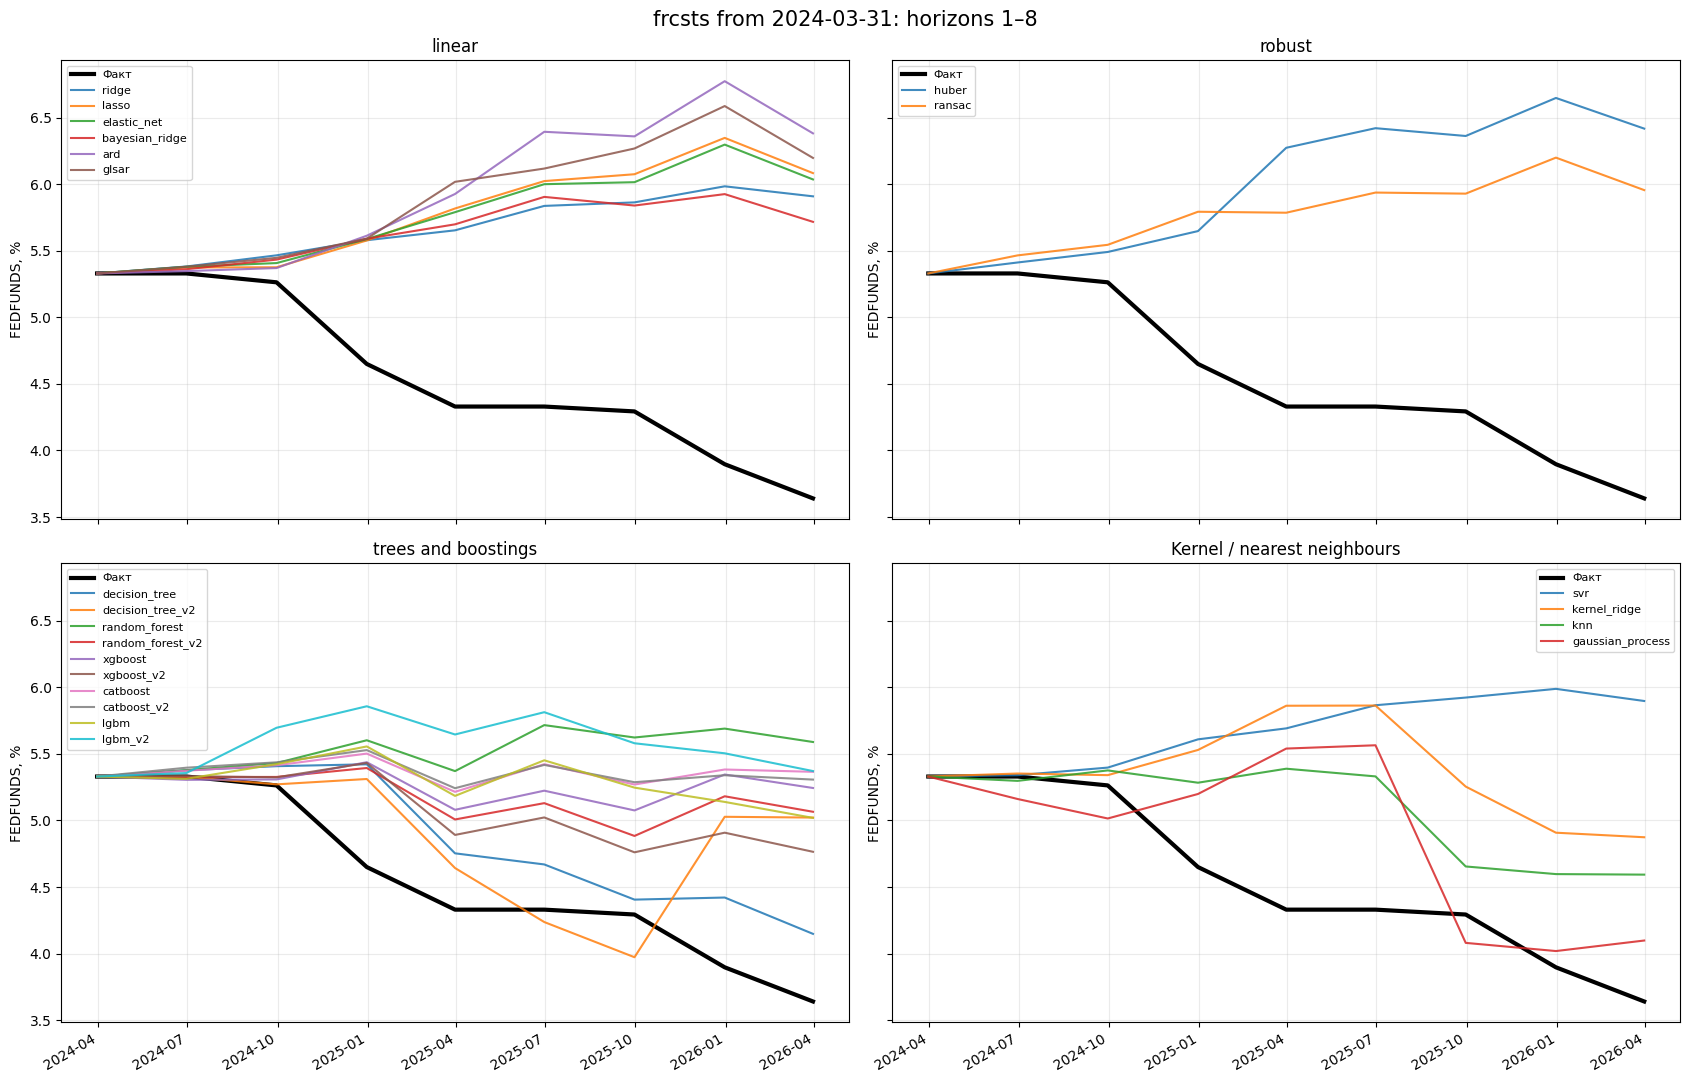

In [66]:
origin = train_end
future_dates = data_full.index[data_full.index > origin][:8]
forecast_trajectory = pd.DataFrame({'Date': [origin, *future_dates],
                                    'Факт': fedfunds_level.loc[[origin, *future_dates]].values})

for name in MODEL_NAMES:
    predicted_diffs = [models_by_h[h][name].predict(features_full[h].loc[[origin]])[0]
                       for h in range(1, len(future_dates) + 1)]
    forecast_trajectory[name] = [fedfunds_level.loc[origin],
                                 *(fedfunds_level.loc[origin] + np.cumsum(predicted_diffs))]

groups = {
    'linear': ['ridge', 'lasso', 'elastic_net', 'bayesian_ridge', 'ard', 'glsar'],
    'robust': ['huber', 'ransac'],
    'trees and boostings': ['decision_tree', 'decision_tree_v2', 'random_forest', 'random_forest_v2',
                           'xgboost', 'xgboost_v2', 'catboost', 'catboost_v2', 'lgbm', 'lgbm_v2'],
    'Kernel / nearest neighbours': ['svr', 'kernel_ridge', 'knn', 'gaussian_process']
}

fig, axes = plt.subplots(2, 2, figsize=(17, 11), sharex=True, sharey=True)
for ax, (title, names) in zip(axes.ravel(), groups.items()):
    ax.plot(forecast_trajectory.Date, forecast_trajectory['Факт'], color='black',  lw=3, label='Факт')
    for name in names:
        ax.plot(forecast_trajectory.Date, forecast_trajectory[name],alpha=.85, label=name)
    ax.set_title(title); ax.set_ylabel('FEDFUNDS, %'); ax.grid(alpha=.25); ax.legend(fontsize=8)
fig.suptitle(f'frcsts from {origin.date()}: horizons 1–8', fontsize=15)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()
